In [2]:
import pandas as pd

# ---------------------------------------------------------
# 1. LOAD AND REPRESENT INITIAL DATA
# ---------------------------------------------------------
file_path = '/content/Environment_Temperature_change_E_All_Data_NOFLAG.csv'

# Using a try-except block to handle potential encoding issues common in global datasets
try:
    df = pd.read_csv(file_path, encoding='latin-1')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='utf-8')

print("--- INITIAL DATA REPRESENTATION ---")
print(f"Original Shape: {df.shape}")
print(f"Missing Values Before Cleaning:\n{df.isnull().sum()[df.isnull().sum() > 0].head(5)} ...\n")
print(df.head(2))
print("\n" + "="*50 + "\n")


# ---------------------------------------------------------
# 2. DATA CLEANING & RESHAPING PIPELINE
# ---------------------------------------------------------
print("Executing Data Cleaning Pipeline...\n")

# Step A: Drop redundant identifier columns
df_dropped = df.drop(columns=['Area Code', 'Months Code', 'Element Code'])

# Step B: Reshape from Wide to Long Format (Melt)
df_long = pd.melt(
    df_dropped,
    id_vars=['Area', 'Months', 'Element', 'Unit'],
    var_name='Year',
    value_name='Value'
)

# Step C: Clean and cast the 'Year' feature
df_long['Year'] = df_long['Year'].str.replace('Y', '').astype(int)

# Step D: Pivot 'Element' to isolate targets
df_clean = df_long.pivot_table(
    index=['Area', 'Months', 'Year', 'Unit'],
    columns='Element',
    values='Value'
).reset_index()

# Rename columns to remove spaces (Best practice for scikit-learn compatibility)
df_clean.rename(columns={
    'Temperature change': 'Temperature_Change',
    'Standard Deviation': 'Standard_Deviation'
}, inplace=True)


# ---------------------------------------------------------
# 3. HANDLING MISSING VALUES (IMPUTATION)
# ---------------------------------------------------------
# Sort temporally to ensure interpolation flows in the correct chronological order
df_clean = df_clean.sort_values(by=['Area', 'Months', 'Year'])

# Group by Area and Month to apply linear interpolation accurately
# This ensures we don't bleed data between different countries or seasons
df_clean['Temperature_Change'] = df_clean.groupby(['Area', 'Months'])['Temperature_Change'].transform(
    lambda group: group.interpolate(method='linear')
)
df_clean['Standard_Deviation'] = df_clean.groupby(['Area', 'Months'])['Standard_Deviation'].transform(
    lambda group: group.interpolate(method='linear')
)

# Drop any remaining NaNs (e.g., if the very first year of a specific country was missing)
df_clean.dropna(inplace=True)


# ---------------------------------------------------------
# 4. REPRESENT FINAL CLEANED DATA
# ---------------------------------------------------------
print("--- CLEANED DATA REPRESENTATION ---")
print(f"Final Shape: {df_clean.shape}")
print("\nData Types:")
print(df_clean.dtypes)
print("\nMissing Values Remaining: ", df_clean.isnull().sum().sum())
print("\nHead of Cleaned Data:")
print(df_clean.head())

--- INITIAL DATA REPRESENTATION ---
Original Shape: (9656, 66)
Missing Values Before Cleaning:
Y1961    1369
Y1962    1334
Y1963    1362
Y1964    1404
Y1965    1375
dtype: int64 ...

   Area Code         Area  Months Code   Months  Element Code  \
0          2  Afghanistan         7001  January          7271   
1          2  Afghanistan         7001  January          6078   

              Element Unit  Y1961  Y1962  Y1963  ...  Y2010  Y2011  Y2012  \
0  Temperature change   °C  0.777  0.062  2.744  ...  3.601  1.179 -0.583   
1  Standard Deviation   °C  1.950  1.950  1.950  ...  1.950  1.950  1.950   

   Y2013  Y2014  Y2015  Y2016  Y2017  Y2018  Y2019  
0  1.233  1.755  1.943  3.416  1.201  1.996  2.951  
1  1.950  1.950  1.950  1.950  1.950  1.950  1.950  

[2 rows x 66 columns]


Executing Data Cleaning Pipeline...

--- CLEANED DATA REPRESENTATION ---
Final Shape: (236840, 6)

Data Types:
Element
Area                   object
Months                 object
Year                    in

In [3]:
df_clean.to_csv('Cleaned_Environment_Temperature_Data.csv', index=False)

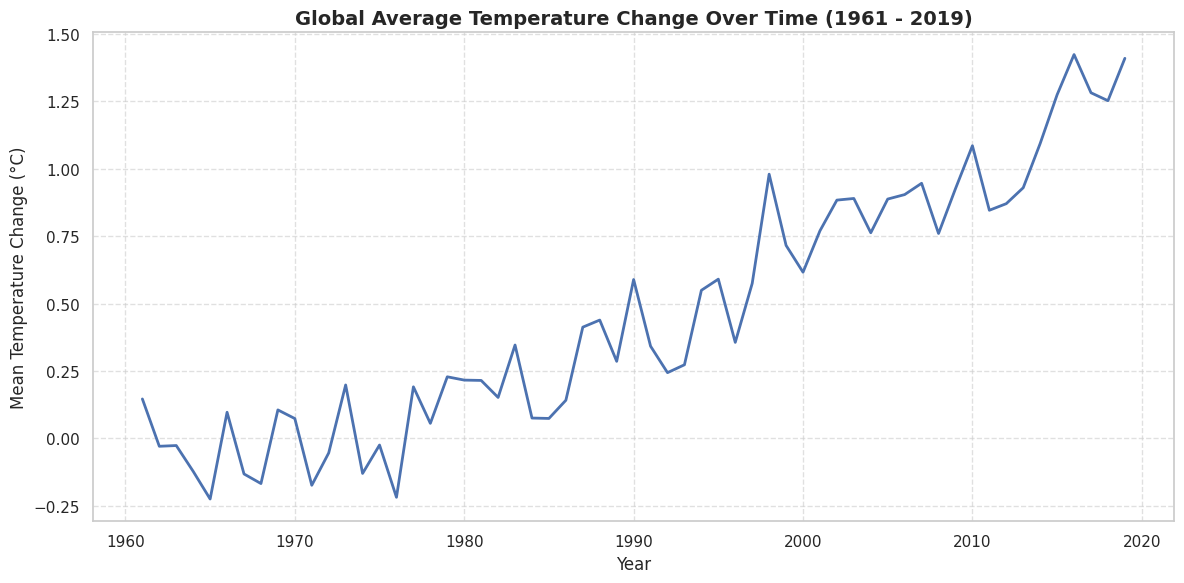

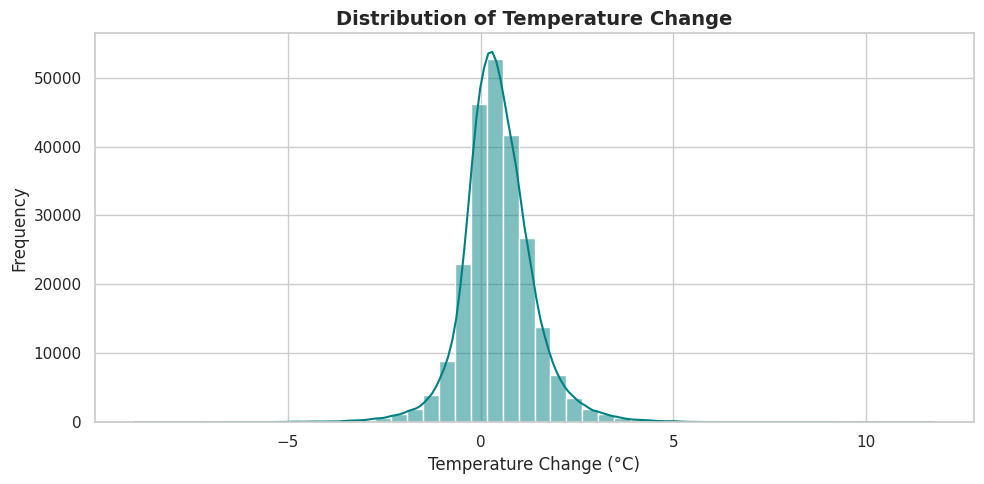

/tmp/ipykernel_1739/891727282.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_areas, x='Temperature_Change', y='Area', palette='coolwarm')


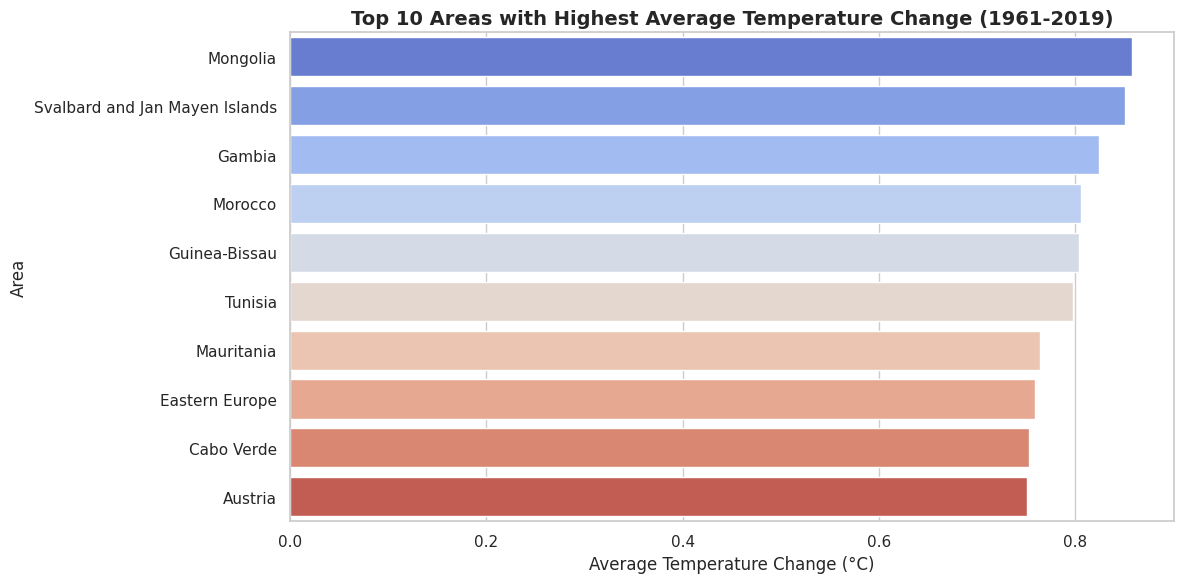

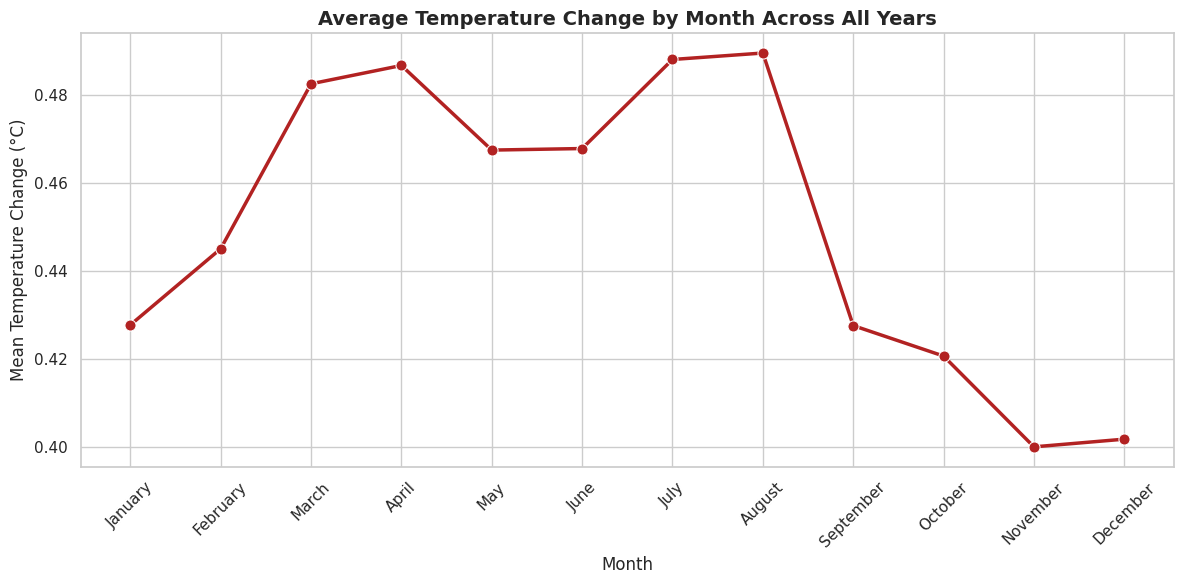

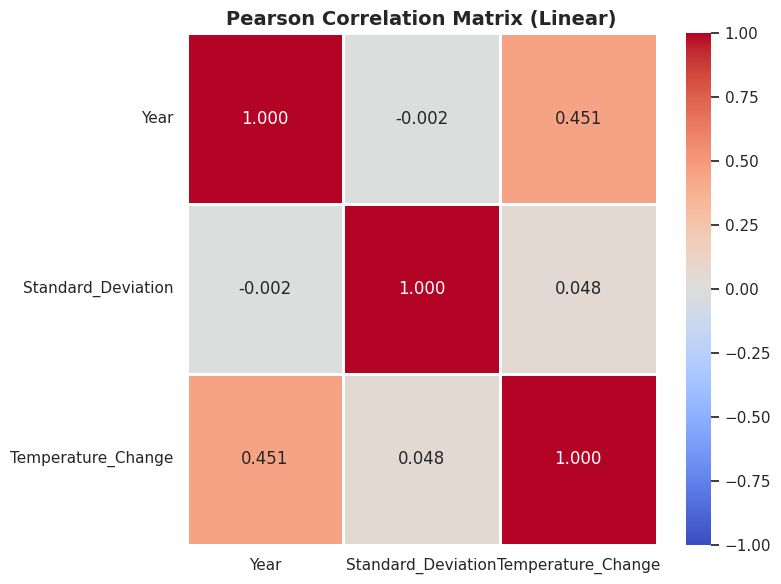

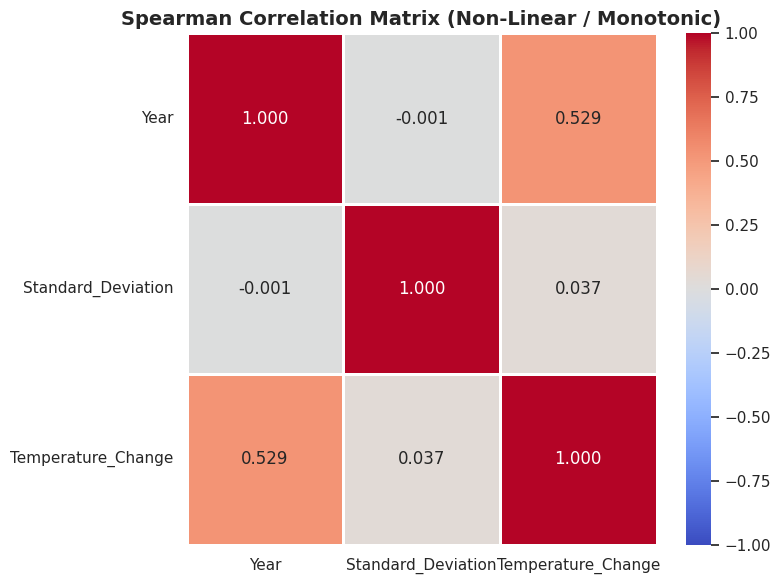

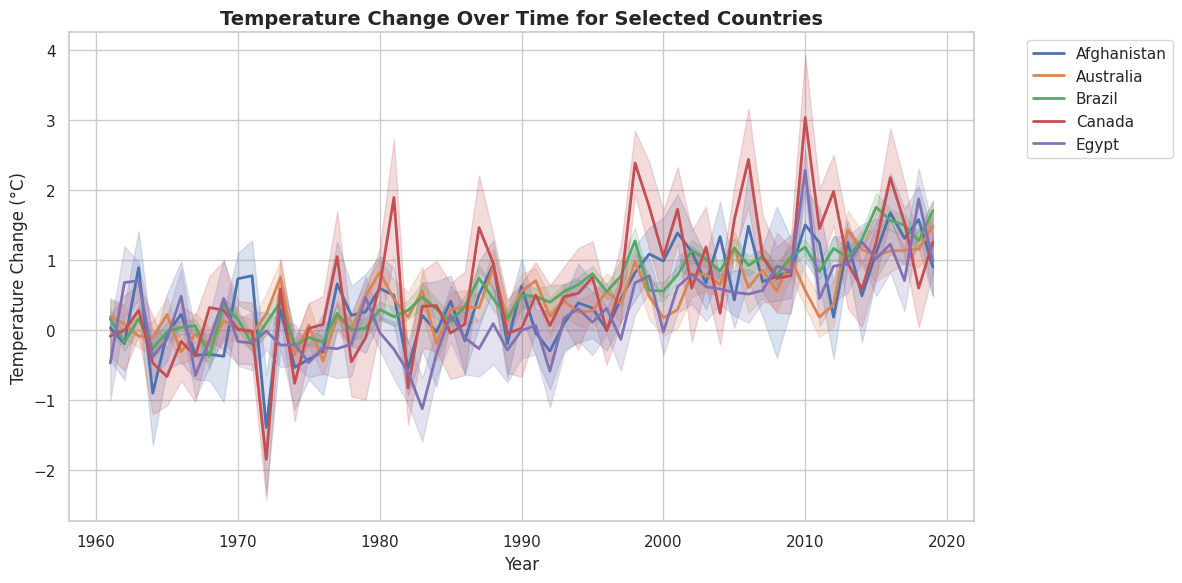

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
df = pd.read_csv('Cleaned_Environment_Temperature_Data.csv')

# Set aesthetic style
sns.set_theme(style="whitegrid")

# 1. Global Average Temperature Change Over Time
plt.figure(figsize=(12, 6))
global_trend = df.groupby('Year')['Temperature_Change'].mean().reset_index()
sns.lineplot(data=global_trend, x='Year', y='Temperature_Change', color='b', linewidth=2)
plt.title('Global Average Temperature Change Over Time (1961 - 2019)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean Temperature Change (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 2. Distribution of Temperature Change
plt.figure(figsize=(10, 5))
sns.histplot(df['Temperature_Change'], kde=True, color='teal', bins=50)
plt.title('Distribution of Temperature Change', fontsize=14, fontweight='bold')
plt.xlabel('Temperature Change (°C)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Top 10 Areas with Highest Average Temperature Change
top_areas = df.groupby('Area')['Temperature_Change'].mean().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=top_areas, x='Temperature_Change', y='Area', palette='coolwarm')
plt.title('Top 10 Areas with Highest Average Temperature Change (1961-2019)', fontsize=14, fontweight='bold')
plt.xlabel('Average Temperature Change (°C)', fontsize=12)
plt.ylabel('Area', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Seasonality: Average Temperature Change by Month
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_trend = df.groupby('Months')['Temperature_Change'].mean().reindex(month_order).reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_trend, x='Months', y='Temperature_Change', marker='o', color='firebrick', linewidth=2.5, markersize=8)
plt.title('Average Temperature Change by Month Across All Years', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Mean Temperature Change (°C)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Pearson Correlation Matrix Heatmap
plt.figure(figsize=(8, 6))
pearson_corr = df[['Year', 'Standard_Deviation', 'Temperature_Change']].corr(method='pearson')
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt='.3f', linewidths=1, cbar=True, vmin=-1, vmax=1)
plt.title('Pearson Correlation Matrix (Linear)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Spearman Correlation Matrix Heatmap (Non-Linear)
plt.figure(figsize=(8, 6))
spearman_corr = df[['Year', 'Standard_Deviation', 'Temperature_Change']].corr(method='spearman')
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt='.3f', linewidths=1, cbar=True, vmin=-1, vmax=1)
plt.title('Spearman Correlation Matrix (Non-Linear / Monotonic)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 7. Regional Comparison Over Time (Sample Countries)
sample_areas = ['Egypt', 'Canada', 'Brazil', 'Australia', 'Afghanistan']
subset_df = df[df['Area'].isin(sample_areas)]
plt.figure(figsize=(12, 6))
sns.lineplot(data=subset_df, x='Year', y='Temperature_Change', hue='Area', linewidth=2)
plt.title('Temperature Change Over Time for Selected Countries', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature Change (°C)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()